In [1]:
# Deep Learning Model to Predict View and Like Count from Features

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from pathlib import Path
from tqdm import tqdm
import ast
import matplotlib.pyplot as plt

In [2]:
# --- CONFIG ---
DATA_FILE = Path("../data/processed/dataset.csv")
CACHE_PATH = Path("../data/processed/engagement_dataset_cache.npz")
TARGET_COLUMNS = ["viewCount", "likeCount"]

In [3]:
# --- Dataset Class ---
class EngagementDataset(Dataset):
    def __init__(self, dataframe):
        emotion_columns = [
            'admiration','amusement','anger','annoyance','approval','caring','confusion','curiosity','desire',
            'disappointment','disapproval','disgust','embarrassment','excitement','fear','gratitude','grief','joy',
            'love','nervousness','optimism','pride','realization','relief','remorse','sadness','surprise','neutral','change_points'
        ]

        if CACHE_PATH.exists():
            cache = np.load(CACHE_PATH)
            self.X_seq = cache['X_seq']
            self.X_static = cache['X_static']
            self.y = cache['y']
            return

        static_features = dataframe.drop(columns=["video_id"] + TARGET_COLUMNS + emotion_columns)
        emotion_sequences = []

        for _, row in dataframe.iterrows():
            emotion_vector = []
            for col in emotion_columns:
                parsed = ast.literal_eval(row[col])
                emotion_vector.append(parsed)
            emotion_vector = np.array(emotion_vector).T
            emotion_sequences.append(emotion_vector)

        self.X_seq = np.array(emotion_sequences).astype(np.float32)
        self.X_static = static_features.values.astype(np.float32)
        self.y = np.log1p(dataframe[TARGET_COLUMNS].values.astype(np.float32))

        np.savez(CACHE_PATH, X_seq=self.X_seq, X_static=self.X_static, y=self.y)

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X_seq[idx]),
            torch.tensor(self.X_static[idx]),
            torch.tensor(self.y[idx])
        )

In [39]:
# --- Quantile Loss ---
def tilted_loss(q, y, f):
    e = y - f
    return torch.mean(torch.max(q * e, (q - 1) * e))

In [ ]:
# --- Transformer + Residual + Separate Heads + Quantiles ---
class EngagementModel(nn.Module):
    def __init__(self, seq_input_dim, static_input_dim, hidden_size, transformer_heads, dropout, embed_dim=128):
        super().__init__()
        
        self.seq_embed = nn.Linear(seq_input_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=transformer_heads,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.attn = nn.Linear(embed_dim, 1)

        self.seq_fc = nn.Sequential(
            nn.Linear(embed_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.static_fc = nn.Sequential(
            nn.Linear(static_input_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Point estimates
        self.views_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
        self.likes_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

        # Quantile estimates
        self.views_head_p10 = nn.Linear(hidden_size, 1)
        self.views_head_p90 = nn.Linear(hidden_size, 1)
        self.likes_head_p10 = nn.Linear(hidden_size, 1)
        self.likes_head_p90 = nn.Linear(hidden_size, 1)

    def forward(self, x_seq, x_static):
        x_seq = self.seq_embed(x_seq)  # Add embedding layer
        x_seq = self.transformer(x_seq)
        attn_weights = torch.softmax(self.attn(x_seq), dim=1)
        seq_repr = (x_seq * attn_weights).sum(dim=1)
        seq_out = self.seq_fc(seq_repr)
        static_out = self.static_fc(x_static)
        combined = seq_out + static_out

        return {
            'views_mean': self.views_head(combined),
            'likes_mean': self.likes_head(combined),
            'views_p10': self.views_head_p10(combined),
            'views_p90': self.views_head_p90(combined),
            'likes_p10': self.likes_head_p10(combined),
            'likes_p90': self.likes_head_p90(combined)
        }

In [41]:
# --- Postprocessing Utility ---
def inverse_transform_and_clip(preds, scaler, percentile_bounds=(5, 95)):
    preds_np = np.expm1(preds)
    preds_unscaled = scaler.inverse_transform(preds_np)
    clipped = np.clip(
        preds_unscaled,
        np.percentile(preds_unscaled, percentile_bounds[0], axis=0),
        np.percentile(preds_unscaled, percentile_bounds[1], axis=0)
    )
    return clipped

In [29]:
# --- Model Config ---
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 5e-4
TRANSFORMER_HEADS = 4
HIDDEN_SIZE = 128
DROPOUT = 0.15

In [6]:
# --- Load Data ---
df = pd.read_csv(DATA_FILE)
dataset = EngagementDataset(df)

val_size = int(0.05 * len(dataset))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE)

In [43]:
# --- Initialize Model ---
seq_input_dim = dataset.X_seq.shape[2]
static_input_dim = dataset.X_static.shape[1]
model = EngagementModel(seq_input_dim=seq_input_dim, static_input_dim=static_input_dim,
                        hidden_size=HIDDEN_SIZE, transformer_heads=TRANSFORMER_HEADS, dropout=DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.HuberLoss()
mae_criterion = nn.L1Loss()
writer = SummaryWriter(log_dir="../models/runs")

In [44]:
# --- Training Loop ---
train_losses, val_losses, train_maes, val_maes = [], [], [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_train_loss, epoch_train_mae = [], []
    for xb_seq, xb_static, yb in train_dl:
        xb_seq, xb_static, yb = xb_seq.to(DEVICE), xb_static.to(DEVICE), yb.to(DEVICE)
        out = model(xb_seq, xb_static)
        pred = torch.cat([out['views_mean'], out['likes_mean']], dim=1)
        loss = criterion(pred, yb)
        mae = mae_criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_loss.append(loss.item())
        epoch_train_mae.append(mae.item())

    model.eval()
    epoch_val_loss, epoch_val_mae = [], []
    with torch.no_grad():
        for xb_seq, xb_static, yb in val_dl:
            xb_seq, xb_static, yb = xb_seq.to(DEVICE), xb_static.to(DEVICE), yb.to(DEVICE)
            out = model(xb_seq, xb_static)
            pred = torch.cat([out['views_mean'], out['likes_mean']], dim=1)
            loss = criterion(pred, yb)
            mae = mae_criterion(pred, yb)
            epoch_val_loss.append(loss.item())
            epoch_val_mae.append(mae.item())

    train_losses.append(np.mean(epoch_train_loss))
    val_losses.append(np.mean(epoch_val_loss))
    train_maes.append(np.mean(epoch_train_mae))
    val_maes.append(np.mean(epoch_val_mae))

    writer.add_scalars("Loss", {"Train": train_losses[-1], "Val": val_losses[-1]}, epoch)
    writer.add_scalars("MAE", {"Train": train_maes[-1], "Val": val_maes[-1]}, epoch)
    print(f"Epoch {epoch}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, Train MAE={train_maes[-1]:.4f}, Val MAE={val_maes[-1]:.4f}")

Epoch 1: Train Loss=13.1789, Val Loss=1.6890, Train MAE=13.6647, Val MAE=2.1714
Epoch 2: Train Loss=4.3761, Val Loss=4.6947, Train MAE=4.8525, Val MAE=5.1916
Epoch 3: Train Loss=3.4627, Val Loss=1.6669, Train MAE=3.9339, Val MAE=2.1283
Epoch 4: Train Loss=2.7416, Val Loss=2.4131, Train MAE=3.2043, Val MAE=2.9071
Epoch 5: Train Loss=3.8914, Val Loss=2.0355, Train MAE=4.3662, Val MAE=2.5192
Epoch 6: Train Loss=2.1265, Val Loss=2.7195, Train MAE=2.5809, Val MAE=3.2079
Epoch 7: Train Loss=1.7972, Val Loss=1.0953, Train MAE=2.2366, Val MAE=1.5434
Epoch 8: Train Loss=1.3223, Val Loss=0.9038, Train MAE=1.7517, Val MAE=1.3474
Epoch 9: Train Loss=1.4839, Val Loss=3.1345, Train MAE=1.9154, Val MAE=3.5286
Epoch 10: Train Loss=1.4182, Val Loss=0.6061, Train MAE=1.8494, Val MAE=0.9393
Epoch 11: Train Loss=0.9378, Val Loss=0.6732, Train MAE=1.3360, Val MAE=1.0457
Epoch 12: Train Loss=0.8345, Val Loss=1.5715, Train MAE=1.2176, Val MAE=2.0491
Epoch 13: Train Loss=1.4102, Val Loss=0.6013, Train MAE=1.8

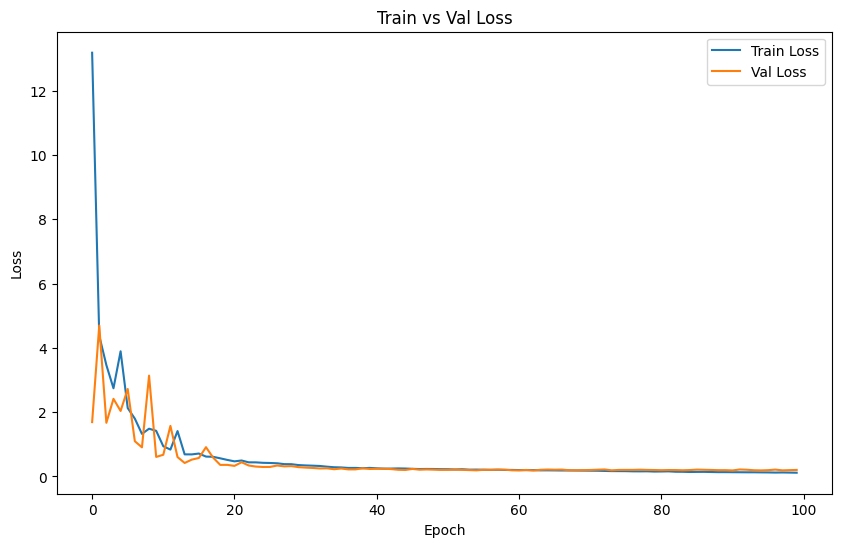

In [ ]:
# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Val Loss")
plt.legend()
plt.show()

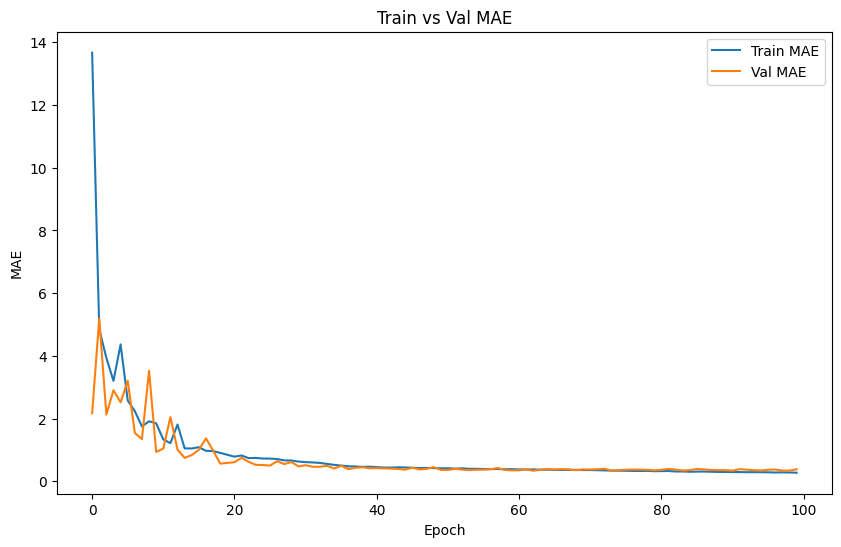

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(train_maes, label="Train MAE")
plt.plot(val_maes, label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Train vs Val MAE")
plt.legend()
plt.show()

In [50]:
import pickle
from random import randint

# --- Manual Testing ---
with torch.no_grad():
    model.eval()
    xb_seq, xb_static, yb = next(iter(val_dl))
    out = model(xb_seq.to(DEVICE), xb_static.to(DEVICE))
    pred = torch.cat([out['views_mean'], out['likes_mean']], dim=1).cpu().numpy()
    y_true = yb.numpy()

    with open('../models/target_scaler.pkl', 'rb') as file:
        loaded_scaler = pickle.load(file)

    pred_unscaled = inverse_transform_and_clip(pred, loaded_scaler)
    y_unscaled = loaded_scaler.inverse_transform(np.expm1(y_true))
    
    rmse = np.sqrt(np.mean((pred_unscaled - y_unscaled) ** 2, axis=0))
    mae = np.mean(np.abs(pred_unscaled - y_unscaled), axis=0)
    
    print("\n--- Inverse Transformed Validation Metrics ---")
    print(f"ViewCount  →  RMSE = {rmse[0]:,.2f}  |  MAE = {mae[0]:,.2f}")
    print(f"LikeCount  →  RMSE = {rmse[1]:,.2f}  |  MAE = {mae[1]:,.2f}")

    for idx in [randint(1, len(pred_unscaled)-1) for _ in range(10)]:
        print(f"Predicted: Views={pred_unscaled[idx][0]:,.0f}, Likes={pred_unscaled[idx][1]:,.0f} | Actual: Views={y_unscaled[idx][0]:,.0f}, Likes={y_unscaled[idx][1]:,.0f}")


--- Inverse Transformed Validation Metrics ---
ViewCount  →  RMSE = 367,099.59  |  MAE = 92,540.30
LikeCount  →  RMSE = 14,402.00  |  MAE = 3,051.98
Predicted: Views=577, Likes=38 | Actual: Views=9, Likes=0
Predicted: Views=32,741, Likes=1,085 | Actual: Views=6,831, Likes=474
Predicted: Views=1,059,972, Likes=11,673 | Actual: Views=749,551, Likes=11,755
Predicted: Views=653, Likes=38 | Actual: Views=21, Likes=0
Predicted: Views=455,902, Likes=8,982 | Actual: Views=365,103, Likes=7,277
Predicted: Views=169, Likes=22 | Actual: Views=389, Likes=15
Predicted: Views=501, Likes=23 | Actual: Views=0, Likes=0
Predicted: Views=541, Likes=26 | Actual: Views=0, Likes=0
Predicted: Views=27, Likes=14 | Actual: Views=7, Likes=20
Predicted: Views=653, Likes=38 | Actual: Views=21, Likes=0


In [51]:
# --- Save the Trained Model ---
MODEL_PATH = Path("../models/engagement_model.pt")
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to ../models/engagement_model.pt
